<a href="https://colab.research.google.com/github/akshitveena/Nakshatra-task-round-2/blob/main/earthquake_damage_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (4000, 37)
Preview:
    building_id  count_floors_pre_eq  age  area_percentage  height_percentage  \
0            0                    3    0               11                  4   
1            1                    1    3               11                  9   
2            2                    2    0               12                  6   
3            3                    1    0               11                  3   
4            4                    2    4               25                 10   

  land_surface_condition foundation_type roof_type ground_floor_type  \
0                      o               r         x                 f   
1                      t               i         x                 v   
2                      t               i         x                 v   
3                      o               r         n                 v   
4                      t               i         n                 f   

  other_floor_type  ... has_secondary_use_hotel ha

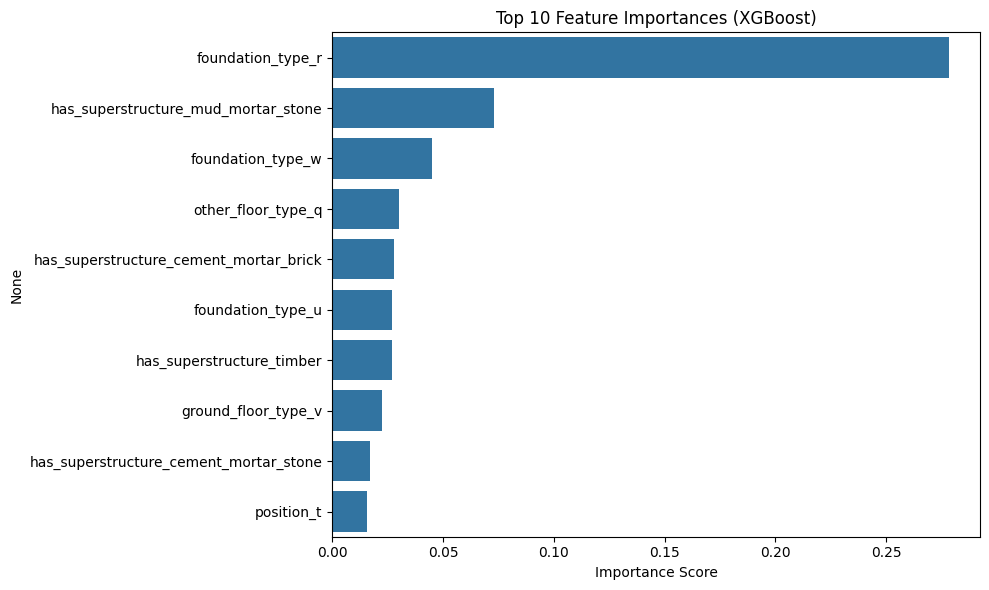

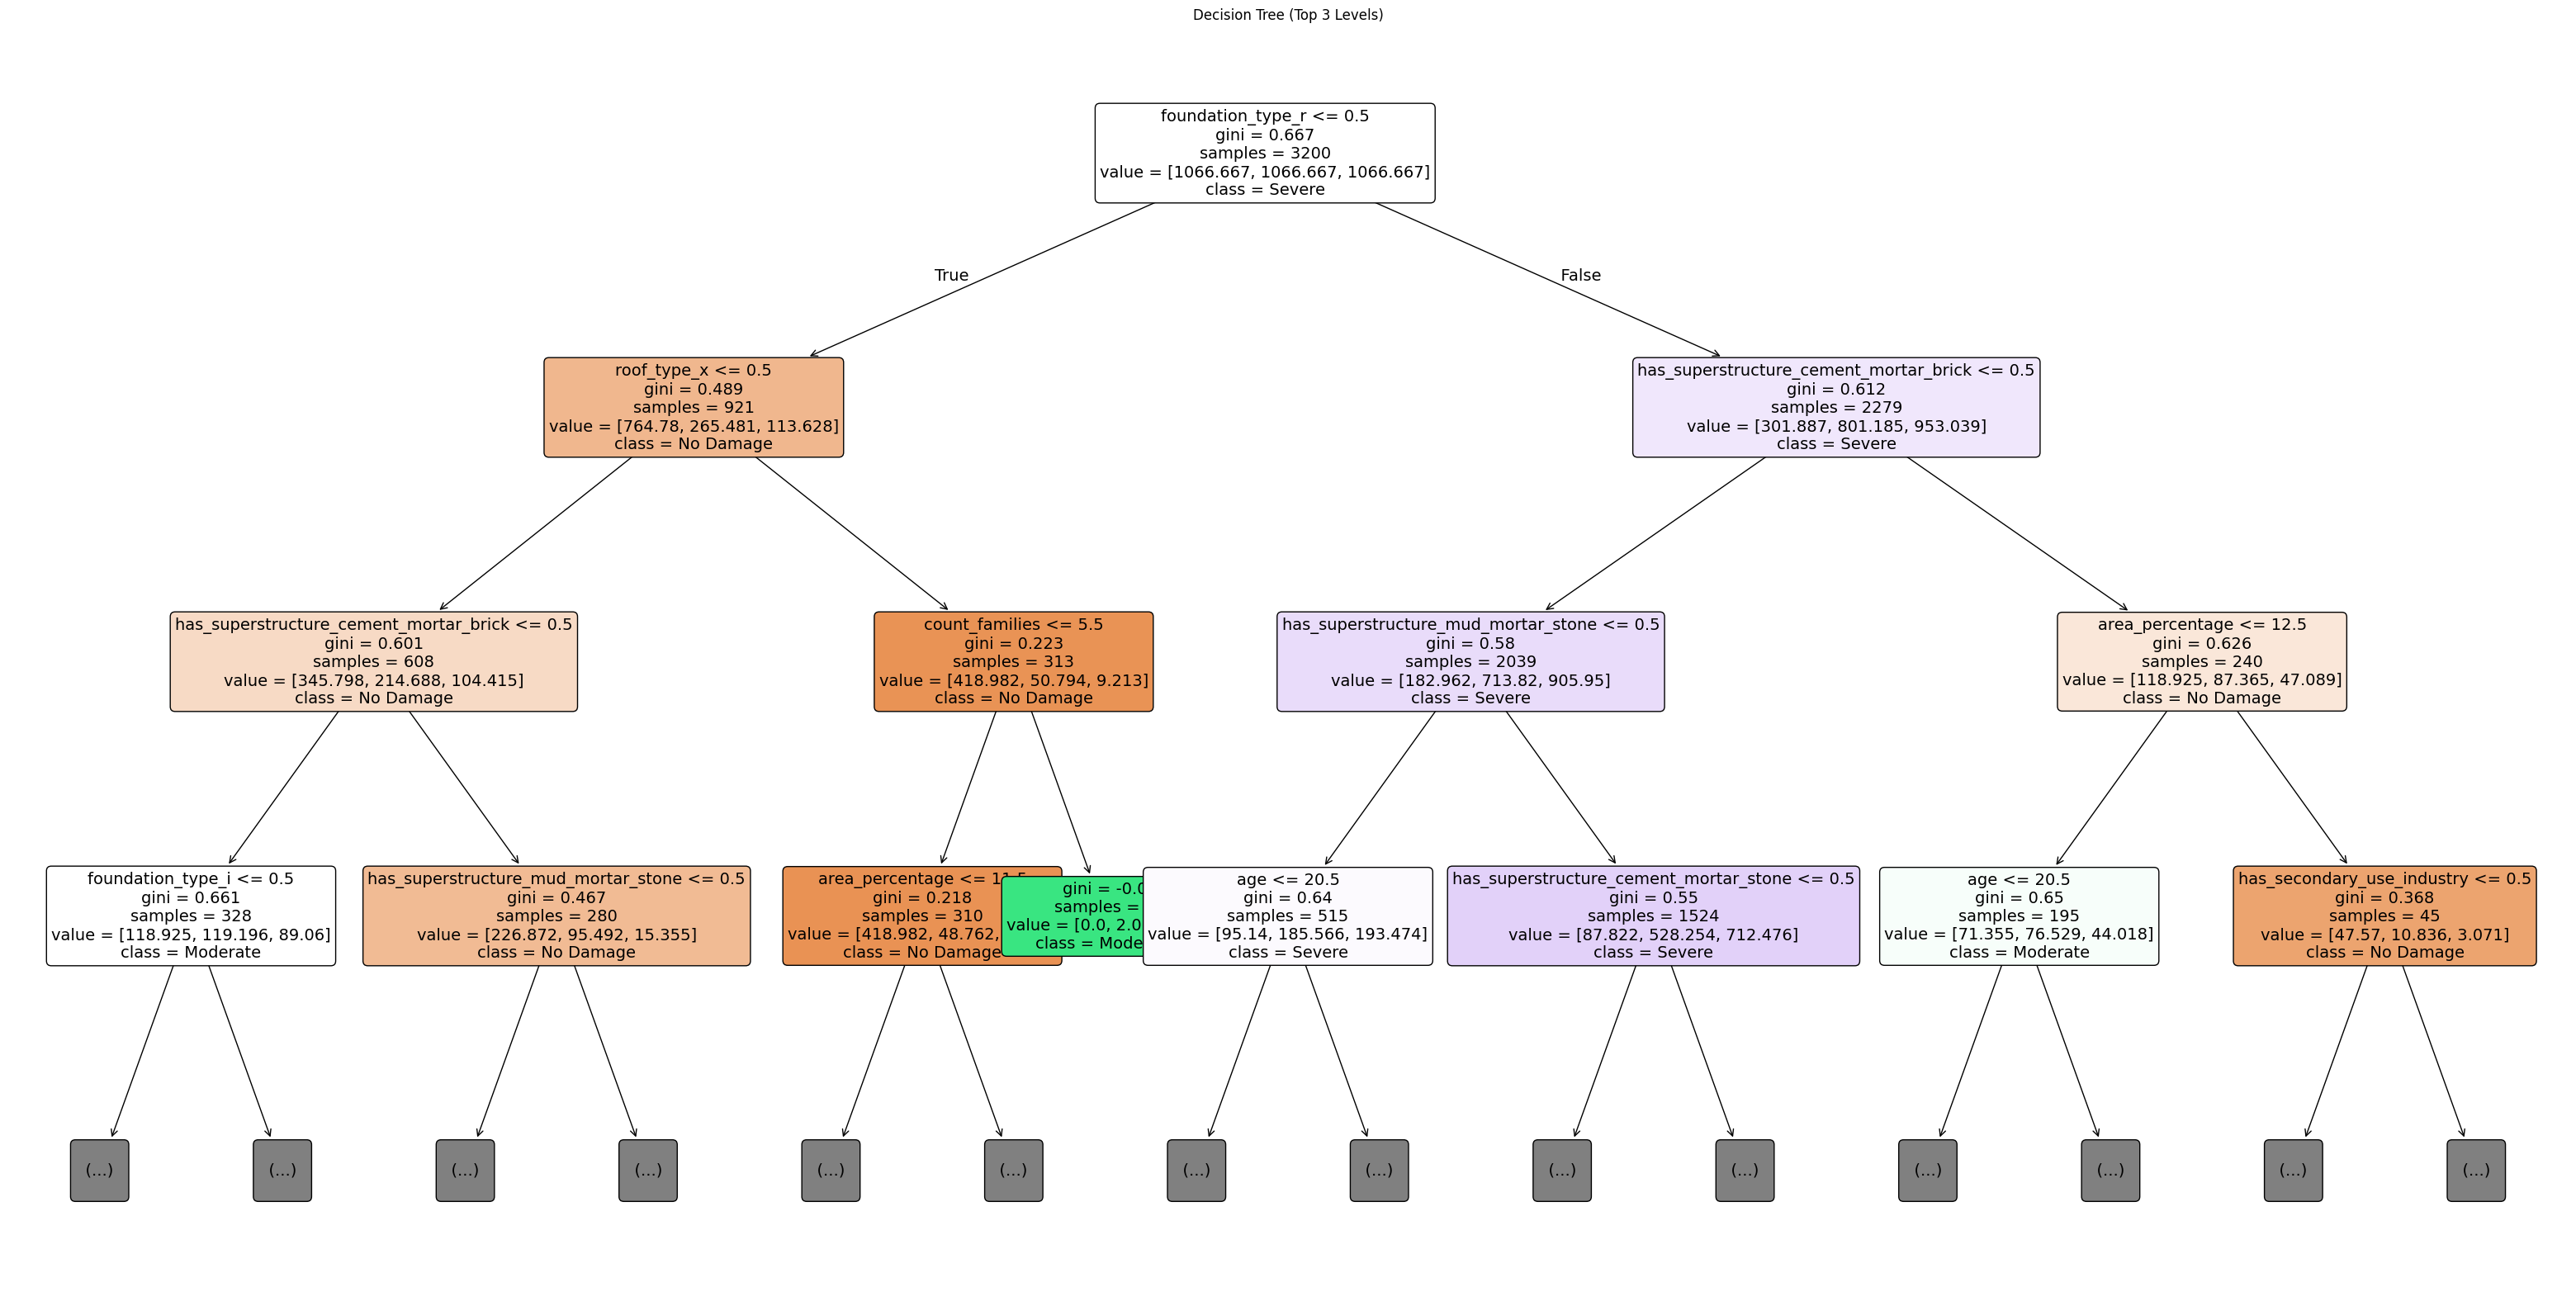

In [19]:
# Earthquake Damage Level Prediction

# 1. Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

# 2. Loading dataset
df = pd.read_csv('train.csv')
print("Dataset Shape:", df.shape)
print("Preview:\n", df.head())

# 3. Preprocessing
df = df.dropna()
df['damage_grade'] = df['damage_grade'] - 1  # convert labels from [1,2,3] → [0,1,2]

X = df.drop('damage_grade', axis=1)
y = df['damage_grade']

# One-hot encode categorical variables
categorical_cols = X.select_dtypes(include='object').columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 4. Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 5. Balance training data with SMOTE (for XGBoost)
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# 6. Decision Tree with GridSearchCV
dt_params = {
    'max_depth': [4, 6, 8, 10],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced']
}

dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, scoring='f1_macro', cv=5)
dt_grid.fit(X_train, y_train)
dt_best = dt_grid.best_estimator_
y_pred_dt = dt_best.predict(X_test)

# 7. XGBoost with tuned parameters
xgb_params = {
    'n_estimators': 150,
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'use_label_encoder': False,
    'eval_metric': 'mlogloss',
    'random_state': 42
}

xgb_model = XGBClassifier(**xgb_params)
xgb_model.fit(X_train_res, y_train_res)
y_pred_xgb = xgb_model.predict(X_test)

# 8. Evaluation
def evaluate(model_name, y_true, y_pred):
    print(f"\n=== {model_name} ===")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['No Damage', 'Moderate', 'Severe']))
    print("Macro F1 Score:", f1_score(y_true, y_pred, average='macro'))

evaluate("Decision Tree (Best GridSearch)", y_test, y_pred_dt)
evaluate("XGBoost (Tuned + SMOTE)", y_test, y_pred_xgb)

# 9. XGBoost(Feature Importance )
importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
top_features = importances.nlargest(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_features, y=top_features.index)
plt.title("Top 10 Feature Importances (XGBoost)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

# 10. Visualizing Decision Tree (Top 3 levels)
plt.figure(figsize=(40, 20))
plot_tree(
    dt_best,
    feature_names=X.columns,
    class_names=['No Damage', 'Moderate', 'Severe'],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=14
)
plt.title("Decision Tree (Top 3 Levels)")
plt.show()
